# Forecast Evaluation

**Author**: Sam Allen (Karlsruhe Institute of Technology)

*This notebook was last tested and operational on 13/07/2026. Please [report any issues](https://github.com/ecmwf-training/2026-ml-esm-training/issues).*

<!-- :::{admonition} About
:class: note, dropdown -->
This notebook was written for the DestinE [2026 Machine Learning for Earth System Modelling Course](https://learning.ecmwf.int/course/view.php?id=99). It was written by Sam Allen whilst working at the Karlsruhe Institute of Technology (KIT), with funding from the Vector Stiftung through the Young Investigator Group "Artificial Intelligence for Probabilistic Weather Forecasting". ChatGPT was used to write some of the plotting functions, and the code to download the WeatherBench 2 data was adapted from code written by Tobias Biegert [here](https://github.com/tobiasbiegert/potential-crps/tree/main/wb2).
<!-- ::: -->

<!-- :::{admonition} Running this notebook
:class: tip, dropdown -->
You may try to run/access this notebook on the free online platforms linked below. Please note they are not officially supported by or linked with ECMWF.

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/2026-ml-esm-training/blob/main/m6/forecast_evaluation_solved.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m6/forecast_evaluation_solved.ipynb)
[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/2026-ml-esm-training/main?binder_path=m6&labpath=m6/forecast_evaluation_solved.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m6/forecast_evaluation_solved.ipynb)

**Important note:**
In contrast to modules 4 and 5, this notebook does not require a GPU, but it does download several GB of data from the [WeatherBench 2](https://sites.research.google/weatherbench/) benchmark (hosted on Google Cloud Storage) and holds it in working memory. So running it requires having a sufficient amount of working memory available. Running the entire notebook takes around an hour, most of which is spent extracting the ensemble forecast data. If this data is too large for your system, the spatial region and time period considered can be restricted (see the first data-loading cells below).

<!--
::: -->

## Introduction

### Forecast evaluation in practice
Here, we illustrate how weather forecasts can be evaluated in practice. We apply established forecast verification tools to gridded temperature forecasts obtained from physics-based and AI-based weather models. The data is extracted from the [WeatherBench 2](https://sites.research.google/weatherbench/) benchmark dataset, highlighting how such benchmarks facilitate a standardised comparison of numerical and AI weather prediction models. We do not cover the more theoretical aspects of the evaluation methods; details can be found in the accompanying lecture and references therein.

### In this notebook
The steps we will follow are:
- Preparing the environment
- Downloading observational reference data
- Evaluating deterministic forecasts issued by deterministic weather models. Specifically, we compare ECMWF's high-resolution physics-based model, _IFS HRES_, to the _GraphCast_ model developed by Google DeepMind, by:
  - Downloading the forecast data
  - Exploring the datasets
  - Comparing the forecasts with observations through evaluation metrics in both time and space
- Evaluating probabilistic forecasts issued by ensemble prediction systems. Specifically, we compare the ECMWF's leading ensemble prediction system, _IFS ENS_, to Google DeepMind's _GenCast_ model, by:
  - Downloading the forecast data
  - Comparing the forecasts with observations through scoring rules in space and time
  - Considering the calibration of the forecasts with rank histograms
- Evaluating binary outcomes in the case of extreme events, by
  - Comparing predictions of extreme temperatures with observations through Brier scores, Murphy diagrams and weighted scoring rules
  - Considering the calibration of the extremes' predictions through reliability diagrams
- Concluding

## Prepare your environment

To facilitate reproducibility, only a handful of packages are used in this notebook:
- `xarray` and `numpy` for data handling
- `matplotlib` and `cartopy` for plotting
- `scoringrules` and `scores` for forecast evaluation

The `scoringrules` package is used to calculate scoring rules for probabilistic forecasts, and the `scores` package is used to produce diagnostic plots to assess forecast calibration. We begin by making sure all these packages are installed.

In [ ]:
%pip install -q -r https://raw.githubusercontent.com/ecmwf-training/2026-ml-esm-training/main/m6/requirements.txt

In [ ]:
# Imports

# For data handling
import xarray as xr
import numpy as np

# For plotting
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# For evaluation
import scoringrules as sr
from scores.probability import rank_histogram, murphy_score
from scores.processing.isoreg_impl import isotonic_fit

## Load Observation Data

To avoid extracting unnecessarily large datasets from WeatherBench 2, which would render the notebook prohibitively long to run, we focus on forecasts for one weather variable (2m temperature), at one lead time (3 days), over one year (2020), and for a subset of grid points in Central and Eastern Europe. We additionally consider the forecasts from WeatherBench 2 with the larger (1.5 degree) spatial resolution. However, the code can easily be adjusted to consider other variables, lead times, and spatial regions; conversely, extracting the ensemble forecast datasets can take some time (~20 mins), and if the data considered herein is too large to be downloaded and stored, then the spatial region and time period of interest could be restricted further.

In [ ]:
var = '2m_temperature'                              # Surface temperature
lead_time = np.timedelta64(3, 'D')                  # Lead time of 3 days
test_time = slice('2020-01-01', '2020-12-31')       # Forecasts issued in 2020
train_time = slice('1980-01-01', '2021-01-10')      # Observation data from 1980
lat_range = slice(30, 80)                           # Latitudes between 30N and 80N
lon_range = slice(0, 50)                            # Longitudes between 0E and 50E

To evaluate the weather models (both deterministic and probabilistic), we require observation data against which the forecasts will be compared. Here, we use ERA5 reanalysis fields as gridded observation fields, acting as the ground truth. These ERA5 fields can be extracted from WeatherBench 2 using the code below. Since AI weather models are generally trained using ERA5 reanalysis fields, this biases the comparison in favour of the AI models. It would be straightforward to instead use IFS analysis fields as the observation data, though since the primary goal of this notebook is to demonstrate the methods that can be used to evaluate forecast performance, this choice is not too important here. This bias should, however, be recognised when interpreting the results.

In [ ]:
# ERA5 observations (loading takes ~ 8 mins)
era5_all = xr.open_zarr(
    store='gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr',
    storage_options={'token': 'anon'}
).sel(
    latitude=lat_range,
    longitude=lon_range,
    time=train_time
)[[var]].load()

# Only observations at 00UTC and 12UTC are considered
era5_all = era5_all.sel(time=(era5_all.time.dt.hour == 0) | (era5_all.time.dt.hour == 12))

The code above extracts the ERA5 reanalysis fields between 1980 and 2020 from Weather Bench 2 and loads them into memory (~ 4 GB). While we only require data from 2020 (and the first few days of 2021) to evaluate the forecasts, we additionally use the 40 years of ERA5 reanalyses between 1980 and 2019 to estimate the average monthly temperature at each grid point, which is required to calculate the anomaly correlation coefficient (ACC), and to estimate the monthly 95% quantile at each grid point, which we later use to define extreme events.

In [ ]:
# Create climatological mean forecast
era5_past = era5_all.sel(time=(era5_all.time.dt.year < 2020) & (era5_all.time.dt.year >= 1980))
era5_2020 = era5_all.sel(time=slice(test_time.start, np.datetime64(test_time.stop) + lead_time))
climatology = era5_past.groupby("time.month").mean("time")
climatology = climatology.sel(month=era5_2020.time.dt.month.data)
climatology = (
    climatology
    .rename({"month": "time"})
    .assign_coords(time=era5_2020.time)
)

# Get 95% threshold (later used to evaluate forecasts for extremes)
thresholds = era5_past.groupby("time.month").quantile(0.95, "time")
thresholds = thresholds.sel(month=era5_2020.time.dt.month.data)
thresholds = (
    thresholds
    .rename({"month": "time"})
    .assign_coords(time=era5_2020.time)
)

# Remove historical ERA5 data that is no longer used to free up memory
del era5_all, era5_past
import gc
_ = gc.collect()


# Deterministic Forecasts

Firstly, suppose we wish to evaluate deterministic weather models, where the forecast on any given day is a single temperature field. In this case, we compare the physics-based IFS HRES model to the AI-based GraphCast model. The IFS HRES and GraphCast forecast fields can be extracted as follows. We align the forecast datasets with the downloaded ERA5 fields to ensure that they correspond to the same time period and spatial region.

## Load Forecast Data

In [ ]:
# Graphcast (loading takes ~ 1 min)
graphcast = xr.open_zarr(
        store='gs://weatherbench2/datasets/graphcast/2020/date_range_2019-11-16_2021-02-01_12_hours-240x121_equiangular_with_poles_conservative.zarr',
        decode_timedelta=True,
        storage_options={'token': 'anon'}
    ).sel(
        time=test_time,
        prediction_timedelta=lead_time,
        latitude=lat_range,
        longitude=lon_range
    )[[var]].load()

In [ ]:
# IFS HRES (loading takes ~ 1 min)
ifs_hres = xr.open_zarr(
    store='gs://weatherbench2/datasets/hres/2016-2022-0012-240x121_equiangular_with_poles_conservative.zarr',
    decode_timedelta=True,
    storage_options={'token': 'anon'}
).sel(
    time=test_time,
    prediction_timedelta=lead_time,
    latitude=lat_range,
    longitude=lon_range
)[[var]].load()

# Convert the forecast time coordinate to the forecast validation time
graphcast = graphcast.assign_coords(time=graphcast.time + lead_time)
ifs_hres = ifs_hres.assign_coords(time=ifs_hres.time + lead_time)

# Align datasets
obs, pred_gc, pred_ifs, pred_clim = xr.align(era5_2020, graphcast, ifs_hres, climatology, join='inner')
lon = obs['longitude'].values
lat = obs['latitude'].values


## Exploratory Analysis

Having extracted the forecast and observation data, we can begin to evaluate the two weather models. However, before doing so, it is often useful to visually inspect the forecasts and observations to check that they are behaving as expected (and to check that there are no obvious errors in the data). To facilitate this, we define two generic functions that we will use throughout this notebook, which allow results to be plotted over time (`plot_ts`) and space (`plot_map`).

In [ ]:
# Function to plot time series
def plot_ts(data, labels, title=None, ylab=None, ax=None, figsize=(10, 4)):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for da, label in zip(data, labels):
        ax.plot(da.time, da.values, label=label)

    ax.set_xlabel("Time")
    if ylab is not None:
        ax.set_ylabel(ylab)
    if title is not None:
        ax.set_title(title)

    ax.legend()

    return fig, ax

In [ ]:
# Function to plot spatial maps
def plot_map(data, lon, lat, title=None, clab=None, vmin=None, vmax=None, fig=None, ax=None):
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # Create colourbar that is blue below zero, red above zero, and white at zero
    if vmin is None:
        vmin = np.min(data)
    if vmax is None:
        vmax = np.max(data)
    n_colors = 256
    frac_neg = -vmin / (vmax - vmin)
    n_neg = int(np.round(frac_neg * n_colors))
    n_neg = np.clip(n_neg, 1, n_colors-1)
    neg_cmap = plt.cm.Blues(np.linspace(1, 0, n_neg))              # blue to white
    pos_cmap = plt.cm.Reds(np.linspace(0, 1, n_colors - n_neg))    # white to red
    combined_cmap = np.vstack([neg_cmap, pos_cmap])
    cmap = mcolors.ListedColormap(combined_cmap)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Create figure
    if ax is None:
            fig, ax = plt.subplots(
                figsize=(4, 5),
                subplot_kw={"projection": ccrs.PlateCarree()}
            )
    else:
        fig = ax.figure

    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree()) # Restrict boundary
    ax.coastlines() # Add coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5) # Add borders

    # Add colour mesh
    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        data.T,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
    )

    # Add contours
    ax.contour(
        lon_grid,
        lat_grid,
        data.T,
        levels=[0.0],
        colors="lightgray",
        linewidths=0.5,
        transform=ccrs.PlateCarree(),
    )

    if title is not None:
        ax.set_title(title)

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        orientation="horizontal",
        shrink=0.8,
        pad=0.08,
    )

    if clab is not None:
        cbar.set_label(clab)

    return fig, ax


We can then simply plot the forecasts and observations over time at a given location. We do this below for a grid point near to Reading, UK, though this could easily be changed by altering `lat_i` and `lon_i` in the following code block (you may consider trying this as a task). Both the physics-based forecasts and the AI-based forecasts appear to accurately capture the general trends in the temperature observations. The climatological monthly average temperature at this grid point is also shown for comparison.

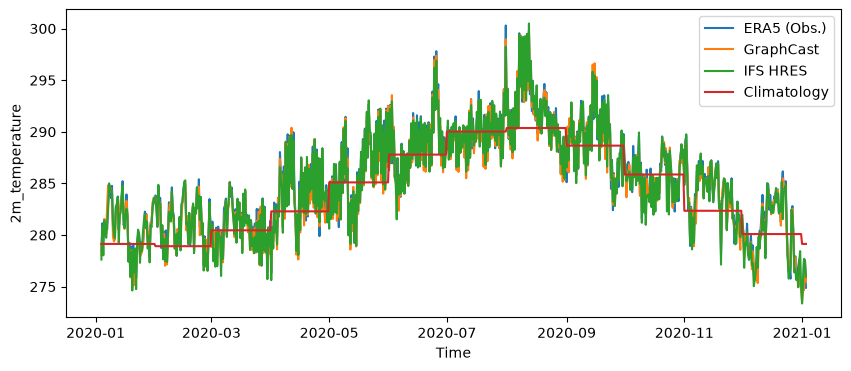

In [ ]:
# Location close to Reading, UK
lat_i = 51.0
lon_i = 0.0

# Restrict the observation and forecasts at this location
obs_i = obs[var].sel(latitude=lat_i, longitude=lon_i, method='nearest')
pred_gc_i = pred_gc[var].sel(latitude=lat_i, longitude=lon_i, method='nearest')
pred_ifs_i = pred_ifs[var].sel(latitude=lat_i, longitude=lon_i, method='nearest')
pred_clim_i = pred_clim[var].sel(latitude=lat_i, longitude=lon_i, method='nearest')

# Plot the forecasts
_ = plot_ts([obs_i, pred_gc_i, pred_ifs_i, pred_clim_i], ["ERA5 (Obs.)", "GraphCast", "IFS HRES", "Climatology"], ylab=var)

We can additionally visualise the spatial region of interest by plotting the climatological average temperature at each grid point. This is displayed below for three months (January, May, September) using the `plot_map` function mentioned above. The overall pattern in the temperature fields is not surprising; grid points at lower latitudes typically have a higher average temperature than grid points at higher latitudes, while temperatures in May and September are generally much larger than those in January.

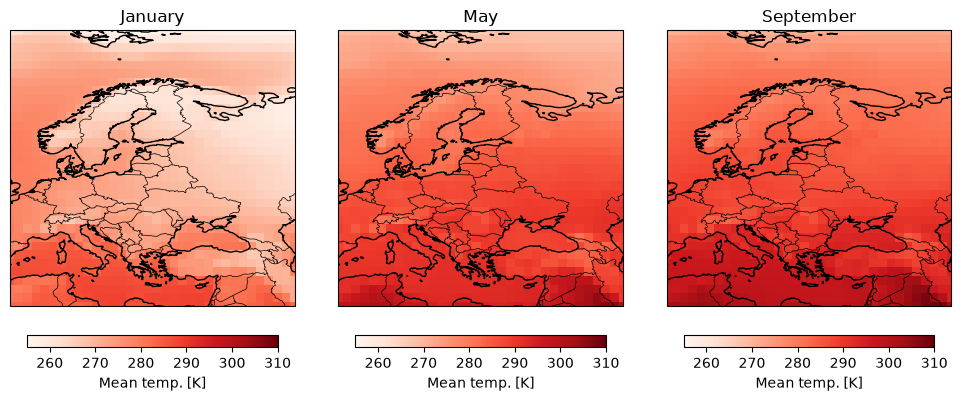

In [ ]:
# Plot average temperature at each grid point in January, May, and September
fig, axes = plt.subplots(1, 3, figsize=(10, 4), subplot_kw={"projection": ccrs.PlateCarree()})

# January
jan_temp = pred_clim[var].sel(time="2020-01-01T12:00:00", method='nearest')
plot_map(jan_temp, lon, lat, title="January", clab="Mean temp. [K]", vmin=255, vmax=310, ax=axes[0])

# May
may_temp = pred_clim[var].sel(time="2020-05-01T12:00:00", method='nearest')
plot_map(may_temp, lon, lat, title="May", clab="Mean temp. [K]", vmin=255, vmax=310, ax=axes[1])

# September
sep_temp = pred_clim[var].sel(time="2020-09-01T12:00:00", method='nearest')
plot_map(sep_temp, lon, lat, title="September", clab="Mean temp. [K]", vmin=255, vmax=310, ax=axes[2])

fig.tight_layout()
plt.show()

## Forecast Comparison

### Evaluation Metrics

We can compare the IFS HRES and GraphCast forecasts using evaluation metrics. Evaluation metrics condense forecast performance into a single numerical value, allowing competing forecasts to be ranked according to the value assigned to them. These evaluation metrics are often obtained from scoring functions (or scoring rules in the case of probabilistic forecasts) averaged over several forecast cases. For example, popular scoring functions include the Absolute Error and Squared Error, which yield the Mean Absolute Error (MAE) and Mean Squared Error (MSE) when averaged over many forecast cases.

However, useful evaluation metrics also exist that are not scoring functions. A popular example in the weather forecasting community is the anomaly correlation coefficient (ACC), which corresponds to the correlation between the forecasts and observations after subtracting the climatology. This is not a scoring function since it cannot be used to evaluate only a single forecast and observation, though it can still provide us with useful information regarding forecast performance. In particular, it ignores constant biases in the forecasts, and therefore provides a rough measure of the information content in the forecast.

In the following, we return the Absolute Error, Squared Error, ACC, and the forecast bias (i.e. the difference between the forecast and the observation) for the IFS HRES and GraphCast forecasts. The Absolute Error, Squared Error, and bias are available at each point in time and space, whereas the ACC is calculated using the entire time series at each grid point, and hence only one ACC value is available for each location.

In [ ]:
# Calculate and store absolute error, squared error, and bias

# IFS HRES
metrics_ifs = xr.concat(
    [
        abs(obs - pred_ifs),                    # Absolute error
        (obs - pred_ifs) ** 2,                  # Squared error
        pred_ifs - obs,                         # Bias
    ],
    dim=xr.IndexVariable("metric", ["ae", "se", "bias"]),
)

# GraphCast
metrics_gc = xr.concat(
    [
        abs(obs - pred_gc),                    # Absolute error
        (obs - pred_gc) ** 2,                  # Squared error
        pred_gc - obs,                         # Bias
    ],
    dim=xr.IndexVariable("metric", ["ae", "se", "bias"]),
)

In [ ]:
# Function to calculate anomaly correlation coefficient
def acc_func(obs, pred, clim):
    pred_anom = pred - clim
    obs_anom = obs - clim
    return (pred_anom * obs_anom).sum('time') / np.sqrt((pred_anom**2).sum('time') * ((obs_anom**2).sum('time')))


acc_ifs = acc_func(obs, pred_ifs, pred_clim)
acc_gc = acc_func(obs, pred_gc, pred_clim)

### Performance over Time

We can plot the MAE, MSE, and mean bias of the forecasts over time. In this case, we average the results over all grid points. This averaging over grid points should be performed using a latitude weighting to account for the fact that different grid points generally correspond to spatial regions of different sizes.

Lower values of the MAE and MSE are preferred, since this suggests that the forecast are in some sense "closer" to the observation fields. We see that the MAE and MSE are generally lower for GraphCast than for IFS HRES across all of 2020. Temperatures in this region appear to be most predictable between June and October, reflected by the smallest MAE and MSE values in these months, while temperatures are less predictable between December and April. The results are qualitatively very similar for the MAE and MSE.

The final panel below shows the average bias of the forecasts. Ideally, the average bias should be close to zero, in which case there is no systematic deviation between the average forecast value and the average observed value. The average bias of the GraphCast forecast is generally close to zero across the whole year. In contrast, the IFS HRES model appears to exhibit a slight negative bias at the beginning of the year (i.e. the forecast is smaller than the observation on average), and little bias in the middle of the year.

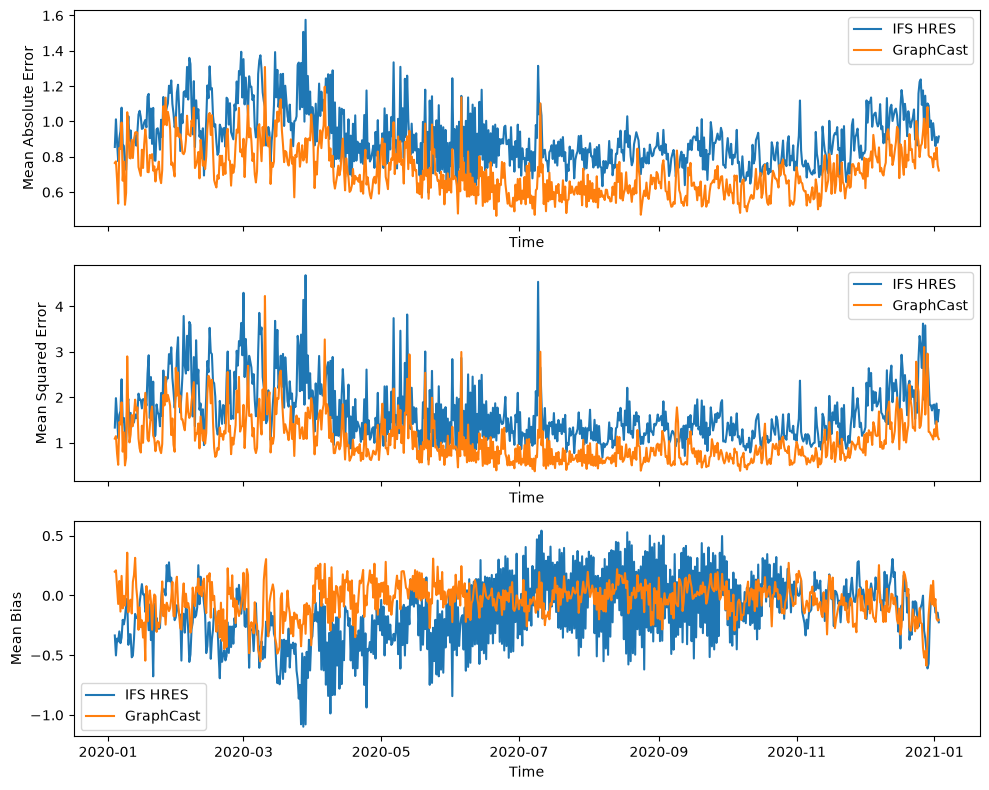

In [ ]:
# Plot time series of MAE, MSE, and bias
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

plot_ts(
    [metrics_ifs.sel(metric='ae').mean(dim=['longitude', 'latitude'])[var],
     metrics_gc.sel(metric='ae').mean(dim=['longitude', 'latitude'])[var]],
    ["IFS HRES", "GraphCast"],
    ylab="Mean Absolute Error",
    ax=axes[0]
)

plot_ts(
    [metrics_ifs.sel(metric='se').mean(dim=['longitude', 'latitude'])[var],
     metrics_gc.sel(metric='se').mean(dim=['longitude', 'latitude'])[var]],
    ["IFS HRES", "GraphCast"],
    ylab="Mean Squared Error",
    ax=axes[1]
)

plot_ts(
    [metrics_ifs.sel(metric='bias').mean(dim=['longitude', 'latitude'])[var],
     metrics_gc.sel(metric='bias').mean(dim=['longitude', 'latitude'])[var]],
    ["IFS HRES", "GraphCast"],
    ylab="Mean Bias",
    ax=axes[2]
)

fig.tight_layout()
plt.show()

### Performance over Space

The evaluation metrics calculated above are also returned for each grid point, allowing us to investigate how forecast performance changes over space. In this case, we average the Absolute Error, Squared Error, and bias at each grid point over all forecast cases in 2020. The ACC is immediately available at all grid points without averaging over time.

We can plot the spatial distribution of the metrics for each weather model separately, though since we are interested in comparing the two models, it is arguably more informative to consider the relative improvement of one model upon another. This can be achieved using _skill scores_. Skill scores quantify the factor by which the score is improved by using one forecast model relative to a baseline model. The following plots show the relative improvement of the GraphCast forecasts upon the baseline IFS HRES model when assessed using the MSE and the ACC. In all cases, a higher skill score suggests that GraphCast issues more accurate forecasts; a positive skill score indicates that GraphCast forecasts perform better than IFS HRES, while a negative skill score indicates that IFS HRES forecasts perform better.

Note that the term "skill" often refers to the improvement of a weather model relative to a climatological baseline forecast, though it can more generally be used to refer to the improvement relative to any baseline model, and we refer to it here as the relative improvement of the AI-based GraphCast model upon the physics-based IFS HRES model. This allows us to determine whether AI-based forecasts improve upon traditional physics-based forecasts.

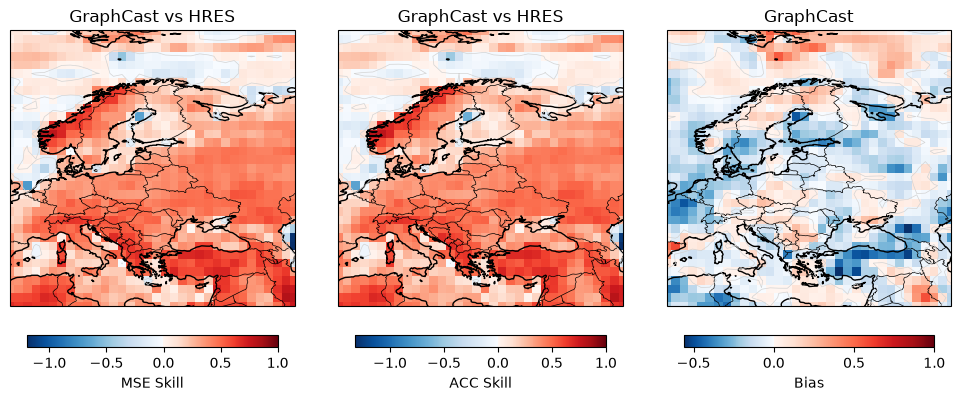

In [ ]:
# Plot average temperature at each grid point in January, May, and September
fig, axes = plt.subplots(1, 3, figsize=(10, 4), subplot_kw={"projection": ccrs.PlateCarree()})

# MSE skill
diff = 1.0 - (metrics_gc.sel(metric='se').mean(dim='time') / metrics_ifs.sel(metric='se').mean(dim='time'))
plot_map(diff[var], lon, lat, title="GraphCast vs HRES", clab="MSE Skill", vmax=1, ax=axes[0])

# ACC skill
diff = (acc_gc - acc_ifs)/(1 - acc_ifs)
plot_map(diff[var], lon, lat, title="GraphCast vs HRES", clab="ACC Skill", vmax=1, ax=axes[1])

# Bias
diff = metrics_gc.sel(metric='bias').mean(dim='time')
plot_map(diff[var], lon, lat, title="GraphCast", clab="Bias", vmax=1, ax=axes[2])

fig.tight_layout()
plt.show()


The spatial plots suggest that the GraphCast forecasts are more accurate than the IFS HRES forecasts at almost all grid points over land, whereas the IFS HRES forecasts often have a slight advantage over lakes and seas. This is true for both the MSE and the ACC, with the relative improvements very similar in both cases.

The final panel above displays the average bias in the GraphCast forecasts at all grid points, which shows that the model exhibits a slight negative bias over Türkiye, despite offering the largest relative improvements upon the IFS HRES forecasts in this region. However, the average bias at all grid points is less than one degree.

# Probabilistic Forecasts

Consider now the case where the forecasts are not single point (or deterministic) forecasts, but instead take the form of an ensemble. Here, an ensemble forecast corresponds to a collection of possible weather fields that could occur. Such forecasts are probabilistic, since they allow us to calculate probabilities associated with different outcomes. These probabilities can then be used to aid decision-making and risk assessment, and probabilistic forecasts are therefore much more informative than single point forecasts.

We evaluate the probabilistic counterparts of the GraphCast and IFS HRES models, called GenCast and IFS ENS, respectively. The time period and spatial region of interest is as in the deterministic case, though we now have ensemble forecasts comprised of 50 members, or samples. Extracting and storing this data may therefore be prohibitively computationally expensive.

In [ ]:
# Graphcast (~ 20 mins)
gencast = xr.open_zarr(
        store='gs://weatherbench2/datasets/gencast/2020-240x121_equiangular_with_poles_conservative.zarr',
        decode_timedelta=True,
        storage_options={'token': 'anon'}
    ).sel(
        time=test_time,
        prediction_timedelta=lead_time,
        latitude=lat_range,
        longitude=lon_range
    )[[var]].load()

In [ ]:
# IFS ensemble (~ 20 mins)
ifs_ens = xr.open_zarr(
        store='gs://weatherbench2/datasets/ifs_ens/2018-2022-240x121_equiangular_with_poles_conservative.zarr',
        decode_timedelta=True,
        storage_options={'token': 'anon'}
    ).sel(
        time=test_time,
        prediction_timedelta=lead_time,
        latitude=lat_range,
        longitude=lon_range
    )[[var]].load()
ifs_ens = ifs_ens.rename({"number": "sample"})

gencast = gencast.assign_coords(time=gencast.time + lead_time)
ifs_ens = ifs_ens.assign_coords(time=ifs_ens.time + lead_time)

# Align ensemble forecasts with the ERA5 observations
obs, pred_gen, pred_ens, thresholds = xr.align(era5_2020, gencast, ifs_ens, thresholds, join="inner")


## Forecast Comparison

We first perform _relative_ forecast evaluation, in the sense that we compare the two forecast methods. This is achieved using _proper scoring rules_. Scoring rules are extensions of (consistent) scoring functions to the case of probabilistic forecasts; they provide a measure of how "close" a probabilistic forecast is to a corresponding observation, and competing forecasts can therefore be ranked using the average score assigned to them over several forecast cases, with a lower score indicating a more accurate forecast. A scoring rule is _proper_ if, when we believe that the outcomes will arise according to a certain distribution, then our expected score is minimised when we issue this distribution as our forecast. This therefore discourages us from making arbitrary changes to our forecast (such as trivially increasing/decreasing the forecast spread) in order to get a better score. Put differently, if we know the true data generating process underlying the observations, then we are encouraged to issue this as our forecast distribution, since no other distribution will receive a better score on average.

Other evaluation metrics exist that are not proper scoring rules. However, if we evaluate forecasts using a scoring rule, then this scoring rule should be proper. If a scoring rule is not proper, then it suggests a forecast exists that would perform better than the true data generating process. In this case, it is not straightforward to intepret the scores, since it is not clear that a lower score corresponds to a better forecast. A comparison using improper scoring rules is therefore not very meaningful.

In the following, the forecasts are evaluated using the Continuous Ranked Probability Score (CRPS), which is by far the most widely-used scoring rule in the weather forecasting literature. The CRPS has the advantage that it can easily be computed for points forecasts, ensemble forecasts, and probabilistic forecasts that are not ensembles, allowing forecasts of different types to be compared.

The CRPS is calculated for each time point and each grid point separately. In doing so, it ignores the spatial structure of the forecast fields. Hence, we additionally employ multivariate scoring rules to assess how well the forecasts capture the dependence between the temperature at different grid points; note that the term "multivariate" here refers to multiple grid points, rather than multiple weather variables (this is due to a difference in how the term "multivariate" is used in the statistics and climate science literatures). We employ the _Energy Score_, which is a multivariate generalisation of the CRPS, and the _Variogram Score_, which focuses evaluation on the dependence between grid points.

In [ ]:
# Calculate the CRPS for each time and grid point
crps_ens = sr.crps_ensemble(obs[var], pred_ens[var], m_axis=1)
crps_gen = sr.crps_ensemble(obs[var], pred_gen[var], m_axis=1)

In [ ]:
# Calculate the Energy score and Variogram score for each time - the different grid points correspond to the different dimensions

# Flatten forecasts and observations across the latitudes and longitudes
pred_ens_flat = pred_ens[var].stack(spatial=("latitude", "longitude"))
pred_gen_flat = pred_gen[var].stack(spatial=("latitude", "longitude"))
obs_flat = obs[var].stack(spatial=("latitude", "longitude"))

# IFS ENS
metrics_ens = xr.concat(
    [
        # Energy score
        xr.apply_ufunc(sr.es_ensemble,
                       obs_flat,
                       pred_ens_flat,
                       input_core_dims=[["spatial"], ["sample", "spatial"]],
                       vectorize=True),
        # Variogram score
        xr.apply_ufunc(sr.vs_ensemble,
                       obs_flat,
                       pred_ens_flat,
                       input_core_dims=[["spatial"], ["sample", "spatial"]],
                       vectorize=True)
    ],
    dim=xr.IndexVariable("metric", ["es", "vs"]),
)

# GenCast
metrics_gen = xr.concat(
    [
        # Energy score
        xr.apply_ufunc(sr.es_ensemble,
                       obs_flat,
                       pred_gen_flat,
                       input_core_dims=[["spatial"], ["sample", "spatial"]],
                       vectorize=True),
        # Variogram score
        xr.apply_ufunc(sr.vs_ensemble,
                       obs_flat,
                       pred_gen_flat,
                       input_core_dims=[["spatial"], ["sample", "spatial"]],
                       vectorize=True)
    ],
    dim=xr.IndexVariable("metric", ["es", "vs"]),
)

# Convert CRPS np arrays to xr DataArrays
crps_ens = xr.DataArray(crps_ens, coords=obs[var].coords, dims=obs[var].dims)
crps_gen = xr.DataArray(crps_gen, coords=obs[var].coords, dims=obs[var].dims)

### Performance over Time

The following plots display the CRPS, Energy Score, and Variogram Score of the IFS ENS and GenCast forecasts across 2020. The Energy Score and Variogram Score both assign one score to each observation field, whereas the CRPS is available for all grid points, and is therefore averaged over all locations in the time series plots.

The conclusions drawn from all three scoring rules are the same: GenCast issues more accurate temperature forecast fields than IFS ENS when evaluated against ERA5 reanalysis fields. This mirrors the results obtained for GraphCast and IFS HRES. Forecast performance is again worst between December and May, and best between June and October.

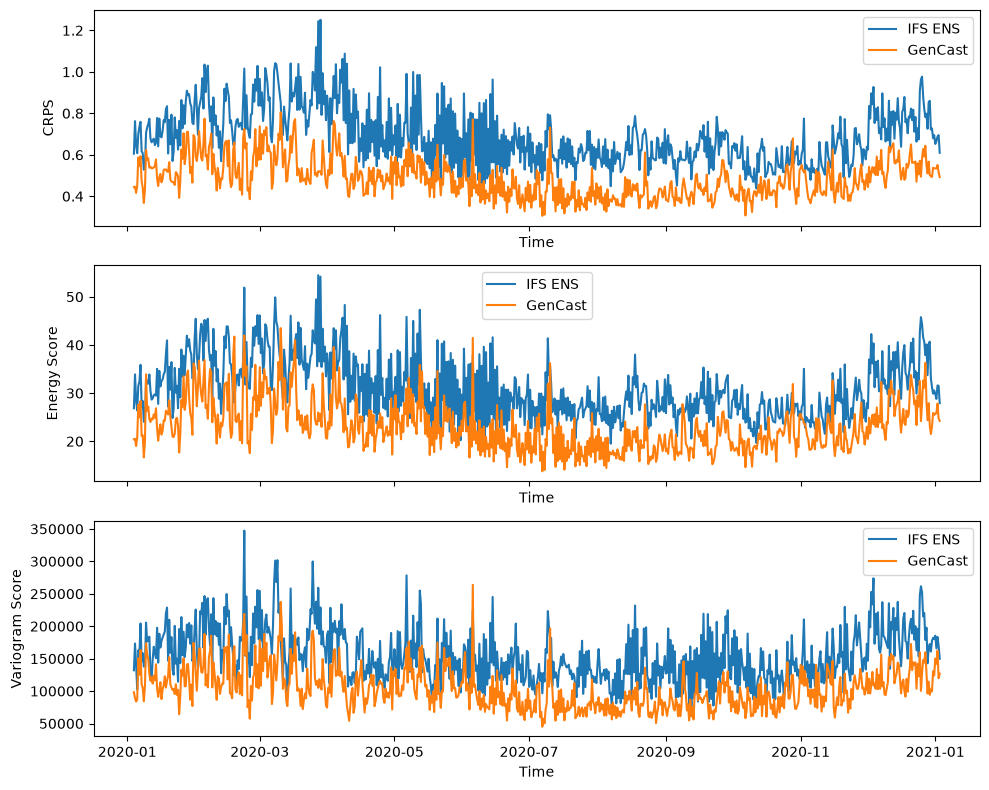

In [ ]:
# Plot time series of MAE, MSE, and bias
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# CRPS
plot_ts([crps_ens.mean(dim=["longitude", "latitude"]),
         crps_gen.mean(dim=["longitude", "latitude"])],
        ["IFS ENS", "GenCast"], ylab="CRPS", ax=axes[0])

# Energy score
plot_ts([metrics_ens.sel(metric='es'), metrics_gen.sel(metric='es')], ["IFS ENS", "GenCast"], ylab="Energy Score", ax=axes[1])

# Variogram score
plot_ts([metrics_ens.sel(metric='vs'), metrics_gen.sel(metric='vs')], ["IFS ENS", "GenCast"], ylab="Variogram Score", ax=axes[2])

fig.tight_layout()
plt.show()

### Performance over Space

The CRPS can also be displayed at each grid point to assess how forecast performance changes over space. As before, since we are interested in the relative performance of the two forecast methods, we plot the CRPS skill score (CRPSS), defined as the relative improvement of the GenCast forecasts upon the baseline IFS ENS forecasts. When assessed using the CRPSS, the GenCast model is found to outperform the IFS ENS model at almost all grid points, even offering an advantage over lakes and seas, which was not the case for the deterministic weather models.

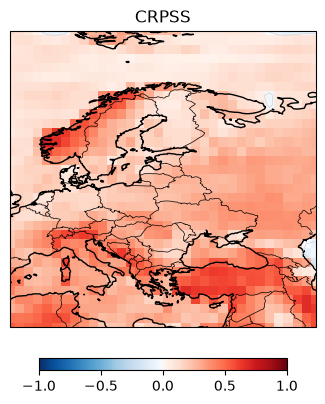

In [ ]:
# Plot relative improvement in CRPS of GenCast upon IFS ENS at each grid point
crpss = 1 - np.mean(crps_gen, axis=0)/np.mean(crps_ens, axis=0)
_ = plot_map(crpss, lon, lat, title = "CRPSS", vmin=-1.0, vmax=1)

## Forecast Calibration

### Rank Histograms

While scoring rules allow us to rank and compare competing weather forecasts, they do not tell us whether the probabilistic forecasts are trustworthy. For example, it could be the case that one model outperforms another model when assessed using the CRPS or Energy Score, but that neither of the models issues reliable forecasts. Hence, it is additionally necessary to assess whether probabilistic forecasts are _calibrated_, which corresponds to checking whether the probabilistic statements made by the forecast distribution align statistically with the corresponding outcomes.

When forecasting univariate outcomes, such as the temperature at a single point in time and space, the calibration of ensemble forecasts can be evaluated using _rank histograms_. Rank histograms calculate the rank of the observation when pooled among the corresponding ensemble members. This is repeated for all forecast cases (i.e. over time and space), and the distribution of the ranks is then plotted in a histogram. If the histogram is flat, then it suggests the forecasts are calibrated. If the histogram is not flat, then the shape of the histogram can be used to identify systematic biases in the forecasts. For example, if the rank of the observation is often larger than the rank of the ensemble members, then it suggests the forecasts exhibit a systematic negative bias; the opposite pattern indicates a positive bias.

Rank histograms can be assessed using the `rank_histogram` function in the `scores` package. We observe that the IFS ENS forecasts are clearly not calibrated, with the observation commonly falling either above or (less often) below the ensemble members, indicating that the forecasts are under-dispersed and negatively biased. In contrast, the GenCast forecasts exhibit much better calibration, with the rank histogram almost flat, though a very slight positive bias is also present. However, it is important to note that the rank histograms below are constructed by aggregating the ranks across all times and grid points, and it may be the case that there are systematic biases in the forecasts at particular times or locations, which average out when all ranks are pooled together. Plotting rank histograms under different conditions would therefore allow us to assess whether the forecasts are conditionally calibrated. Consider trying this out as a task.

In [ ]:
# Function to plot rank histograms
def plot_rank_hist(rank_hist, figsize=(7, 3)):
    _, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=figsize)

    axes[0].bar(rank_hist['rank'].values, rank_hist["IFS ENS"].values, width=1)
    axes[0].axhline(y=1/51, color='k', linestyle='--')
    axes[0].set_title("IFS ENS")
    axes[0].set_xlabel("Rank")
    axes[0].set_ylabel('Relative frequency')

    axes[1].bar(rank_hist['rank'].values, rank_hist["GenCast"].values, width=1)
    axes[1].axhline(y=1/51, color='k', linestyle='--')
    axes[1].set_xlabel("Rank")
    axes[1].set_title("GenCast")

    plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.2, hspace=0.3)

    plt.show()

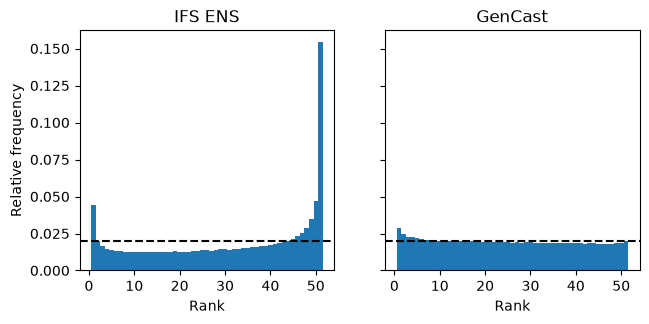

In [ ]:
# Flatten forecasts and observations across all times and grid points
pred_ens_flat_flat = pred_ens[var].stack(case=("time", "latitude", "longitude"))
pred_gen_flat_flat = pred_gen[var].stack(case=("time", "latitude", "longitude"))
obs_flat_flat = obs[var].stack(case=("time", "latitude", "longitude"))

# Calculate and plot the distribution of ranks
rank_hist = rank_histogram(xr.merge([pred_ens_flat_flat.T.rename("IFS ENS"),
                                     pred_gen_flat_flat.T.rename("GenCast")],
                                     compat="no_conflicts"),
                           obs_flat_flat, "sample")
plot_rank_hist(rank_hist)

### Multivariate Rank Histograms

Just as multivariate scoring rules exist to compare forecasts with respect to their multivariate or spatial structure, methods exist to assess the multivariate calibration of probabilistic forecast fields. This allows us to identify whether our forecasts reliably predict dependencies between different grid points, for example.

Evaluating multivariate calibration is generally very difficult, especially since visualising forecast calibration in high dimensions is challenging. Hence, the most common approach to evaluate multivariate calibration in practice is to choose a univariate summary statistic, to calculate this for the observation and for all ensemble members, and then to use rank histograms to assess whether the forecasts are calibrated when predicting this summary statistic. This can be repeated for many summary statistics, to identify whether different aspects of the forecasts are trustworthy; if the forecasts are not calibrated when predicting a summary statistic of interest, then we can similarly use the shape of the resulting histogram to learn what kinds of biases are present in the forecasts.

As a simple example, we evaluate the calibration of our probabilistic temperature fields when predicting the mean temperature across all grid points. This allows us to identify whether the probabilistic forecasts systematically over- or under-predict the average temperature in the field, though we can easily replace the mean with any (possibly more meaningful) summary statistic. The resulting multivariate rank histograms indicate that the IFS ENS forecasts again exhibit a strong negative bias, while the GenCast forecasts again exhibit a positive bias, though the magnitude of this bias is larger than in the univariate case.

Note that, in the univariate case, we have ranks for each forecast time and for each spatial location, whereas in the multivariate case, we only have ranks for each forecast time, since we are using information from the entire grid (or at least a subset of it) to define the summary statistic of interest. As a result, there is generally more uncertainty (or noise) in the multivariate rank histogram than in the univariate rank histogram; if we were to only plot the ranks for one location, then this noise would also be present.

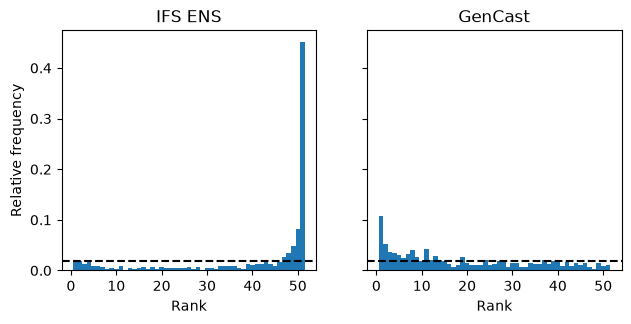

In [ ]:
# Transform forecast and observation fields to univariate summary statistics

# IFS ENS
pred_ens_tr = xr.apply_ufunc(
    np.mean,
    pred_ens_flat,
    input_core_dims=[["spatial"]],
    output_core_dims=[[]],
    kwargs={"axis": -1}
)

# GenCast
pred_gen_tr = xr.apply_ufunc(
    np.mean,
    pred_gen_flat,
    input_core_dims=[["spatial"]],
    output_core_dims=[[]],
    kwargs={"axis": -1}
)
# ERA%
obs_tr = xr.apply_ufunc(
    np.mean,
    obs_flat,
    input_core_dims=[["spatial"]],
    output_core_dims=[[]],
    kwargs={"axis": -1}
)

# Calculate and plot the distribution of ranks of the transformed observations
mv_rank_hist = rank_histogram(xr.merge([pred_ens_tr.rename("IFS ENS"),
                                        pred_gen_tr.rename("GenCast")],
                                       compat="no_conflicts"),
                              obs_tr, "sample")
plot_rank_hist(mv_rank_hist)


# Forecasting Extreme Events

Thus far, we have evaluated how well forecasts perform overall. However, we are often particularly interested in evaluating how well the forecasts perform when forecasting particular outcomes, such as extreme events, since these events may have a larger impact on the forecast users. Hence, an obvious question is: what methods can we use to evaluate forecasts for extreme weather events? We restrict attention to probabilistic forecasts here, since the probabilistic information is particularly valuable when forecasting extreme events.

The methods used to evaluate forecasts for extreme event will, of course, depend on how an extreme event is defined. The definition of an extreme event will change depending on what events are of interest in any given forecasting task, though it is common to define extreme events as exceedances of a relevant threshold, often calculated as a relatively high quantile from previously observed data. Here, we use exceedances of 95% quantiles of the ERA5 data between 1980 and 2019. This is calculated separately at each grid point, so that the definition of an extreme event depends on the local climatology; whether or not this is sensible will depend on the application, though we use this here as an example. We calculated the thresholds previously, when the ERA5 data was first loaded.

In this case, there are two aspects of forecast performance to consider: whether an extreme event occurs, and how severe the event will be when it occurs. In the first case, it is sufficient to consider only the binary event corresponding to whether the observed temperature exceeded the relevant threshold. A probabilistic forecast for this binary event can be obtained by taking the proportion of ensemble members that predict that the threshold will be exceeded. Probabilistic forecasts for binary outcomes are often referred to as _probability_ forecasts, since they correspond to single probabilities.

In [ ]:
# Convert forecasts and observations to binary events
pred_ens_exc = (pred_ens > thresholds).mean(dim="sample")
pred_gen_exc = (pred_gen > thresholds).mean(dim="sample")
obs_exc = (obs > thresholds).astype(int)

## Forecast Comparison

### Scoring Rules for Binary Outcomes

To evaluate the resulting probability forecasts, we can employ scoring rules for binary outcomes. The most widely-used such scoring rule is the _Brier Score_, which corresponds to the Squared Error when evaluating probability forecasts.

By plotting the Brier Score over time (averaged over all grid points), we see that Gencast again outperforms IFS ENS throughout the year, though it could be argued that the improvements appear to be smaller here than when evaluating overall performance using the CRPS and Energy and Variogram Scores.

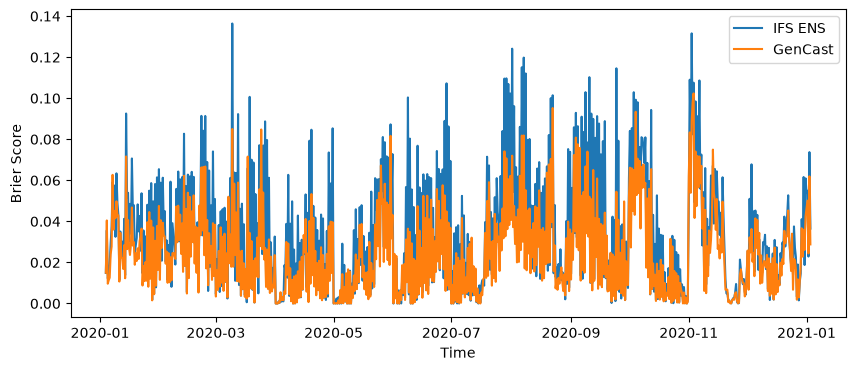

In [ ]:
# Calculate Brier scores
bs_ens = (pred_ens_exc - obs_exc)**2
bs_gen = (pred_gen_exc - obs_exc)**2

# Plot Brier scores over time
_ = plot_ts([bs_ens.mean(dim=['longitude', 'latitude'])[var],
             bs_gen.mean(dim=['longitude', 'latitude'])[var]],
            ["IFS ENS", "GenCast"], ylab="Brier Score")

We can similarly plot the relative improvement in the Brier Score for each grid point. A positive value suggests that GenCast issues more accurate forecasts for the occurrence of extreme temperatures, whereas a negative value suggests that IFS ENS issues more accurate forecasts. Again, the overall pattern is similar to that for overall performance, with GenCast more accurate than IFS ENS at the majority of grid points. However, the Brier skill scores are generally lower than the CRPSS, suggesting the relative improvement of GenCast is less pronounced when forecasting these moderate extremes.

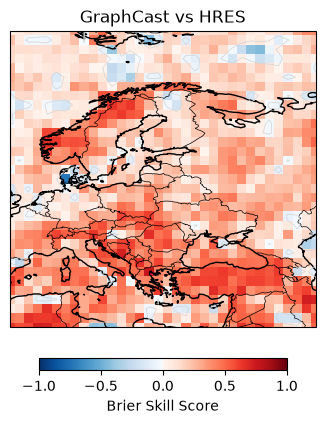

In [ ]:
# Plot Brier scores over space
bss = 1 - bs_gen.mean(dim='time')[var]/bs_ens.mean(dim='time')[var]
_ = plot_map(bss, lon, lat, title="GraphCast vs HRES", clab="Brier Skill Score", vmin=-1.0, vmax=1)

### Murphy Diagrams

While the Brier score is one scoring rule with which to evaluate probability forecasts of binary outcomes, several other proper scoring rules also exist and could similarly be employed to evaluate forecast performance when predicting the occurrence of extreme events. However, it could be the case that one model performs better than another model when evaluated using one scoring rule, but that the other model performs better with respect to another scoring rule. An obvious question then is: what scoring rule(s) should be used in practice?

It can be shown that every proper scoring rule for binary outcomes can be written as a linear combination of so-called _elementary_ scoring rules (also called Murphy scoring rules). As a result, if one model performs better than another with respect to all elementary scoring rules, then it necessarily performs better with respect to all proper scoring rules. In this case, the more accurate model is said to _dominate_ the other model. Forecast dominance can be assessed using _Murphy diagrams_, which plot the elementary score for the competing forecast models against a single parameter that characterises the elementary score. From this, it can be determined whether one forecast dominates another.

Murphy diagrams can be calculated using the `murphy_score` function in the `scores` package. By plotting the Murphy diagram for the GenCast and IFS ENS forecasts (averaged over all times and grid points), we see that the GenCast forecasts receive a lower elementary score for all parameters; that is, GenCast issues more accurate forecasts for extreme temperatures than IFS ENS when evaluated using all elementary scoring rules, and therefore also when evalauted using all proper scoring rules for binary outcomes. Hence, the GenCast dominates the IFS ENS model when forecasting these extreme temperatures.

In [ ]:
# Flatten the probability forecasts and observations across all times and grid points
pred_ens_exc_flat = pred_ens_exc.stack(case=("time", "latitude", "longitude"))
pred_gen_exc_flat = pred_gen_exc.stack(case=("time", "latitude", "longitude"))
obs_exc_flat = obs_exc.stack(case=("time", "latitude", "longitude"))

# Calculate elementary scores for IFS ENS
ms_ens = murphy_score(
    pred_ens_exc_flat[var],
    obs_exc_flat[var],
    thetas=np.linspace(0, 1, 101),
    functional="expectile",
    alpha=0.5
)

# Calculate elementary scores for GenCast
ms_gen = murphy_score(
    pred_gen_exc_flat[var],
    obs_exc_flat[var],
    thetas=np.linspace(0, 1, 101),
    functional="expectile",
    alpha=0.5
)

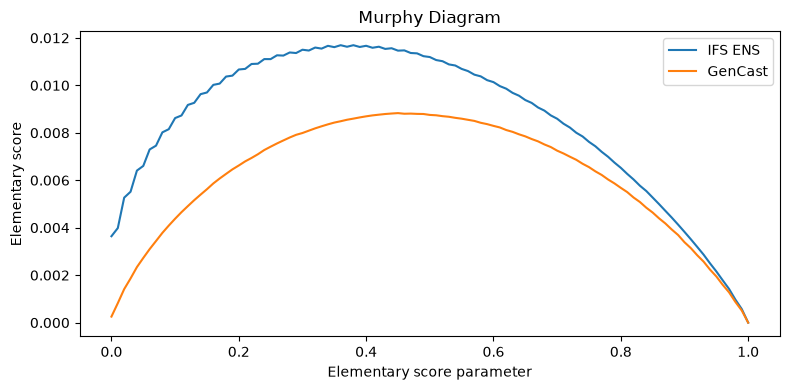

In [ ]:
# Plot Murphy diagram
fig, ax = plt.subplots(figsize=(8, 4))

ms_ens["total"].plot(
    ax=ax,
    label="IFS ENS"
)

ms_gen["total"].plot(
    ax=ax,
    label="GenCast"
)

ax.set_title("Murphy Diagram")
ax.set_xlabel("Elementary score parameter")
ax.set_ylabel("Elementary score")

ax.legend()

plt.tight_layout()
plt.show()

### Weighted Scoring Rules

Scoring rules for binary outcomes allow us to compare forecasts for the occurrence of an extreme event, but they do not evaluate how well the ensemble forecasts capture the severity of an extreme event given that it has occurred. This can be achieved using _weighted scoring rules_. Weighted scoring rules essentially incorporate a weight function into conventional scoring rules, where the weight function can be chosen to emphasise particular outcomes. These have been studied in most detail when interest is on threshold exceedances, where it is common to employ a weight function that is equal to one when the threshold is exceeded, and zero otherwise.

The most well-known weighted scoring rule is the _threshold-weighted CRPS_. The twCRPS is displayed for the IFS ENS and GenCast models below, where interest is on values that exceed the threshold defining the extreme event at each grid point. The results are qualitatively similar to those for the Brier Score: GenCast outperforms IFS ENS at most points in time, though the relative improvement is generally lower than in the overall case. This can also be observed by plotting the twCRPS skill score at each grid point, with GenCast again issuing more accurate forecasts at the majority of locations.

In [ ]:
# Calculate threshold-weighted CRPS

# IFS ENS
twcrps_ens = xr.apply_ufunc(
    sr.twcrps_ensemble,
    obs[var],
    pred_ens[var],
    thresholds[var],
    input_core_dims=[
        [],            # observation is scalar at each time/location
        ["sample"],    # ensemble dimension
        [],            # threshold is scalar at each location (or time/location)
    ],
    output_core_dims=[[]],
    kwargs={"m_axis": -1},
    vectorize=True,
)

# GenCast
twcrps_gen = xr.apply_ufunc(
    sr.twcrps_ensemble,
    obs[var],
    pred_gen[var],
    thresholds[var],
    input_core_dims=[
        [],            # observation is scalar at each time/location
        ["sample"],    # ensemble dimension
        [],            # threshold is scalar at each location (or time/location)
    ],
    output_core_dims=[[]],
    kwargs={"m_axis": -1},
    vectorize=True,
)

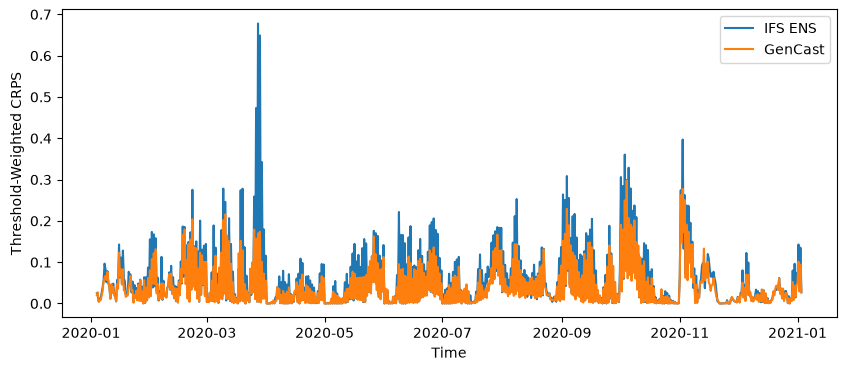

In [ ]:
# Plot twCRPS over time
_ = plot_ts([twcrps_ens.mean(dim=['longitude', 'latitude']),
             twcrps_gen.mean(dim=['longitude', 'latitude'])],
            ["IFS ENS", "GenCast"], ylab="Threshold-Weighted CRPS")

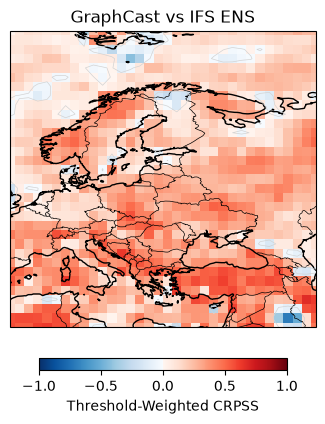

In [ ]:
# Plot twCRPSS over space
twcrpss = 1 - twcrps_gen.mean(dim='time')/twcrps_ens.mean(dim='time')
_ = plot_map(twcrpss, lon, lat, title="GraphCast vs IFS ENS", clab="Threshold-Weighted CRPSS", vmin=-1.0, vmax=1)

While the twCRPS is the mostly widely-used weighted scoring rule, other weighted scoring rules also exist and could similarly be employed to evaluate forecasts for extreme weather events. For example, weighted scoring rules also exist for multivariate forecasts, which could be used to focus on multivariate extreme events when evaluating forecast performance, such as compound weather events.

## Forecast Calibration

While scoring rules allow us to compare competing forecasts, we additionally need to assess whether the forecasts for extreme events are calibrated. When forecasting binary events, forecasts are calibrated if, when the event is forecast to occur with a certain probability, it does indeed transpire with this probability. For example, if we say that it will rain tomorrow with probability 0.2, then this forecast is calibrated if it rains tomorrow with probability 0.2. In practice, we can check whether it rains on 20% of the instances when we issue a forecast probability of 0.2 (and analogously for all other forecast probabilities).

This can be assessed using reliability diagrams, which show the forecast probability against the relative frequency that the event occurs given the forecast. If the forecasts are calibrated, then the curve should lie along the diagonal line. The reliability diagram below suggests that the IFS ENS forecasts are clearly miscalibrated. In particular, the forecast probability is generally too low, suggesting the forecasts underpredict the occurrence of extreme events. This aligns with the conclusion from the rank histograms that the forecasts exhibit a strong negative bias. These reliability diagrams have been constructed using forecasts at all grid points throughout 2020.

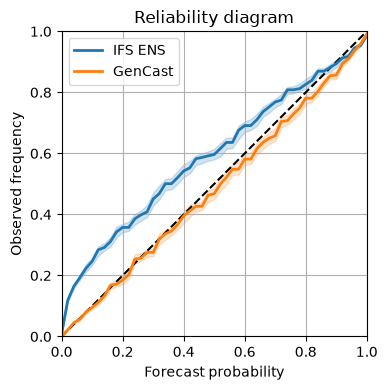

In [ ]:
# Generate reliability diagrams using isotonic regression
iso_fit_ens = isotonic_fit(
    fcst=pred_ens_exc_flat[var],
    obs=obs_exc_flat[var],
    functional="mean",
        bootstraps=100,
    confidence_level=0.95
)

iso_fit_gen = isotonic_fit(
    fcst=pred_gen_exc_flat[var],
    obs=obs_exc_flat[var],
    functional="mean",
    bootstraps=100,
    confidence_level=0.95
)

x_ens = iso_fit_ens["fcst_sorted"]
y_ens = iso_fit_ens["regression_values"]
lower_ens = iso_fit_ens["confidence_band_lower_values"]
upper_ens = iso_fit_ens["confidence_band_upper_values"]

x_gen = iso_fit_gen["fcst_sorted"]
y_gen = iso_fit_gen["regression_values"]
lower_gen = iso_fit_gen["confidence_band_lower_values"]
upper_gen = iso_fit_gen["confidence_band_upper_values"]

fig, ax = plt.subplots(figsize=(4, 4))

# Add diagonal
ax.plot([0, 1], [0, 1], "k--")

# IFS ENS
ax.plot(x_ens, y_ens, color="C0", lw=2, label="IFS ENS")
ax.fill_between(x_ens, lower_ens, upper_ens, color="C0", alpha=0.2)

# GenCast
ax.plot(x_gen, y_gen, color="C1", lw=2, label="GenCast")
ax.fill_between(x_gen, lower_gen, upper_gen, color="C1", alpha=0.2)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Forecast probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Reliability diagram")

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

Reliability diagrams evaluate whether forecasts are reliable when predicting the occurrence of an extreme outcome (or any other binary event). Tools also exist to assess whether forecasts are calibrated when predicting how severe the extreme event will be. This can similarly be achieved using adaptations of rank histograms, and these are typically referred to as _conditional rank histograms_, since we are evaluating calibration conditional on the occurrence of an extreme event.

# Conclusion

This notebook has extracted gridded temperature forecast fields from the WeatherBench 2 benchmark dataset, and evaluated their performance when forecasting ERA5 reanalysis fields. Forecasts obtained from a state-of-the-art physics-based weather model are compared to those obtained from a state-of-the-art AI-based weather model. We consider both point forecasts, generated from deterministic weather models, as well as probabilistic forecasts, generated from ensemble predictive systems. We use evaluation metrics such as scoring rules and scoring functions to rank the two methods, and we additionally assess the calibration of the probabilistic forecasts using reliability diagrams and rank histograms. We assess forecast performance at each grid point separately using univariate methods, as well as evaluating how well the forecasts capture the spatial structure of the temperature fields using multivariate scoring rules and multivariate rank histograms. Finally, we focus on forecasts made for extreme events, and introduce methods to assess probabilistic forecasts for the occurrence and severity of extremes.

The goal of this notebook was to highlight that there are several different aspects to forecast evaluation, particularly when evaluating probabilistic high-dimensional weather forecast fields, and to illustrate the use of popular methods in practice. Forecast evaluation tools allow us to compare competing forecast models, but also to determine whether the forecasts we issue are actually trustworthy, which is necessary for their use in decision making and risk assessment. Ultimately, however, the most suitable methods for forecast evaluation will depend on how the forecasts are to be used, and on what constitutes a "good" forecast for the forecast users.